In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **METODOLOGÍA**

El objetivo de este trabajo es desarrollar una herramienta computacional que apoye el diseño preliminar de puentes reticulados, combinando aprendizaje automático y algoritmos de optimización bioinspirada. La metodología consiste en entrenar una red neuronal profunda capaz de estimar el peso estructural del puente a partir de variables geométricas, y utilizar dicho modelo como función objetivo dentro de un algoritmo PSO.

El sistema permite que el usuario defina ciertas características topológicas del puente, mientras que las variables geométricas continuas son optimizadas automáticamente mediante PSOo, mientras que las variables restantes son optimizadas automáticamente para minimizar el peso estimado.



## **IMPORTACIÓN DE LIBRERIAS**

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# **IMPLEMENTACIÓN**

## **Preprocesamiento de datos**

El conjunto de datos utilizado contiene información geométrica y topológica de diferentes configuraciones de puentes reticulados. Antes del entrenamiento del modelo, se realizó un proceso de limpieza y selección de variables, eliminando características no numéricas y aquellas que no aportan información relevante al modelo.

Posteriormente, los datos fueron normalizados con el objetivo de mejorar la estabilidad del entrenamiento de la red neuronal y asegurar que todas las variables tengan una influencia comparable.

## **Arquitectura del sistema**

El sistema se compone de tres módulos principales: procesamiento de datos, modelo de red neuronal y módulo de optimización. El modelo de red neuronal actúa como un modelo sustituto que estima el peso estructural del puente, mientras que el algoritmo PSO explora distintas configuraciones geométricas hasta encontrar el diseño que minimiza dicho peso.




## **Importar dataframe, variables de entrada y codificación de variables categóricas**

In [4]:
df = pd.read_csv("drive/MyDrive/Trabajo PSO/DATAPUENTE.csv",sep=';', encoding='latin1')

#Limpieza
df.columns = df.columns.str.strip()
df = df.dropna()

df.head()


,Longitud (m),Ancho de Puente (m),Sep Vigas Longitudinales (m),N° Paneles,Altura (m),Disposicion de Arriostre,Forma de Arriostre,Dim. Arriostre,Forma de Cordones,Dimension de Cordon Sup/Inf,Forma de Diagonales,Dim. Diag. S/I,Forma de Montante,Dim. Montante,Peso total (ton)
0,55,11.6,2.1,6,5.5,Cruz,T,150x150x12.5,Cajon HSS,400x410x19.0,Cajon HSS,380x390x16.0,Cajon HSS,200x200x12.5,119.00
1,55,11.6,2.1,6,5.5,Cruz,L,150x150x12.5,Cajon HSS,410x420x19.0,Cajon HSS,390x400x16.0,Cajon HSS,200x200x12.5,122.18
2,55,11.6,2.1,6,5.6,Cruz,T,150x150x12.5,Cajon HSS,420x430x19.0,Cajon HSS,400x410x16.0,Cajon HSS,200x200x12.5,125.46
3,55,11.6,2.1,6,5.6,Cruz,L,150x150x12.5,Cajon HSS,430x400x19.0,Cajon HSS,410x380x16.0,Cajon HSS,200x200x12.5,122.27
4,55,11.6,2.1,6,5.7,Cruz,T,150x150x12.5,Cajon HSS,400x410x19.0,Cajon HSS,380x390x16.0,Cajon HSS,200x200x12.5,119.17


In [5]:
features = [
    'Longitud (m)',
    'Ancho de Puente (m)',
    'Altura (m)',
    'N° Paneles',
    'Sep Vigas Longitudinales (m)',
    'Disposicion de Arriostre',
    'Forma de Arriostre',
    'Forma de Cordones',
    'Forma de Diagonales',
    'Forma de Montante'
]

target = 'Peso total (ton)'

encoders = {}
for col in features:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

## **Modelo de red neuronal profunda**

La red neuronal se entrena con el objetivo de aprender la relación entre la geometría del puente y su peso total. Una vez entrenada, la red se utiliza como modelo predictivo dentro del proceso de optimización.



### Red neuronal

In [6]:
X = df[features].values
y = df[target].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento controlado

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6836 - val_loss: 0.0971
Epoch 2/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1032 - val_loss: 0.0218
Epoch 3/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0518 - val_loss: 0.0162
Epoch 4/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0417 - val_loss: 0.0209
Epoch 5/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0378 - val_loss: 0.0132
Epoch 6/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0289 - val_loss: 0.0147
Epoch 7/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0327 - val_loss: 0.0235
Epoch 8/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0308 - val_loss: 0.0167
Epoch 9/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0285 - val_loss: 0.0148
Epoch 10/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0292 - val_loss: 0.0149
Epoch 11/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0340 - val_loss: 0.0078
Epoch 12/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

## **Evaluación del modelo**

El desempeño del modelo entrenado se evaluó mediante métricas estadísticas como el coeficiente de determinación (R²) y el error absoluto medio (MAE). Estas métricas permiten cuantificar la precisión del modelo y analizar su comportamiento tanto en el conjunto de entrenamiento como en el conjunto de prueba.

Además, se presentan gráficas que comparan los valores reales y los valores estimados del peso estructural.


In [8]:
y_train_pred = scaler_y.inverse_transform(model.predict(X_train))
y_test_pred  = scaler_y.inverse_transform(model.predict(X_test))

y_train_real = scaler_y.inverse_transform(y_train)
y_test_real  = scaler_y.inverse_transform(y_test)

print("R² entrenamiento:", r2_score(y_train_real, y_train_pred))
print("R² test:", r2_score(y_test_real, y_test_pred))

print("MAE test (ton):", mean_absolute_error(y_test_real, y_test_pred))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
R² entrenamiento: 0.9925144464457998
R² test: 0.9920806138033689
MAE test (ton): 8.564511031728658


In [9]:
mae = mean_absolute_error(y_test_real, y_test_pred)
peso_promedio = df["Peso total (ton)"].mean()

error_relativo = (mae / peso_promedio) * 100

print(f"Peso promedio del conjunto: {peso_promedio:.2f} ton")
print(f"MAE del modelo: {mae:.2f} ton")
print(f"Error relativo promedio: {error_relativo:.2f} %")

Peso promedio del conjunto: 310.77 ton
MAE del modelo: 8.56 ton
Error relativo promedio: 2.76 %


El error absoluto medio obtenido representa aproximadamente el 2.6% del peso estructural promedio de los puentes analizados, lo cual resulta aceptable para procesos de optimización preliminar y toma de decisiones en etapas tempranas de diseño.

## **Gráfica de entrenamiento de la DNN**

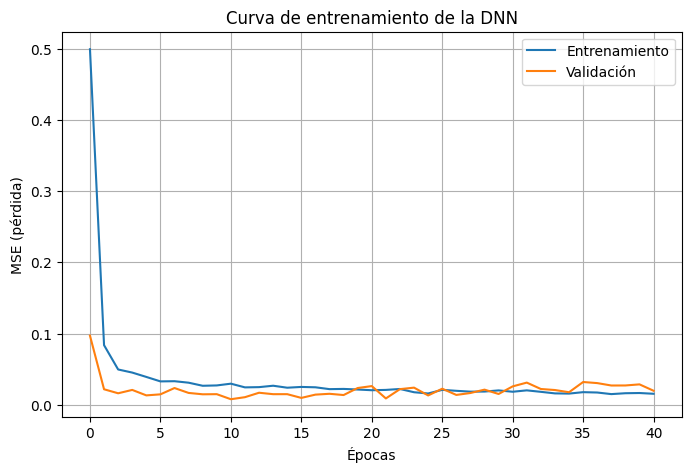

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')

plt.xlabel('Épocas')
plt.ylabel('MSE (pérdida)')
plt.title('Curva de entrenamiento de la DNN')
plt.legend()
plt.grid(True)
plt.show()

La figura muestra la evolución de la función de pérdida durante el entrenamiento del modelo de red neuronal. Se observa una convergencia estable tanto en el conjunto de entrenamiento como de validación, sin evidencias de sobreajuste, lo que confirma la capacidad de generalización del modelo.

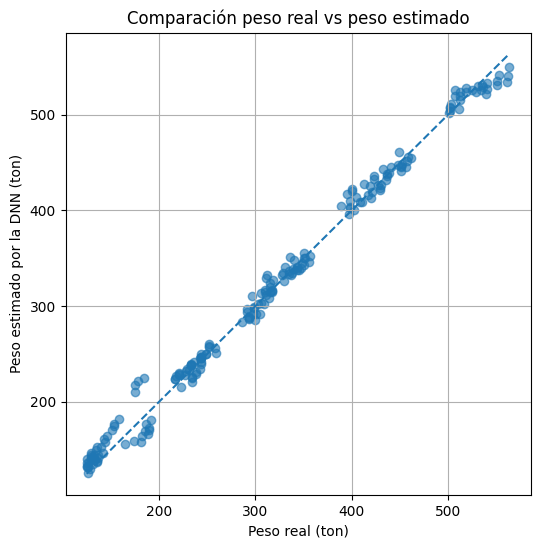

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_test_pred, alpha=0.6)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    linestyle='--'
)
plt.xlabel("Peso real (ton)")
plt.ylabel("Peso estimado por la DNN (ton)")
plt.title("Comparación peso real vs peso estimado")
plt.grid(True)
plt.show()


# **PSO**

## **Optimización asistida por el usuario**

En esta etapa, el usuario define ciertas variables geométricas del puente, las cuales actúan como restricciones iniciales. A partir de estas condiciones, el algoritmo PSO optimiza automáticamente las variables restantes con el objetivo de minimizar el peso estructural estimado por la red neuronal.


In [12]:
# === CONFIGURACIÓN DEL USUARIO ===
'''
user_inputs = {
    "Disposicion de Arriostre": "Cruz",
    "Forma de Arriostre": "T",
    "Forma de Cordones": "Cajon HSS",
    "Forma de Diagonales": "Cajon HSS",
    "Forma de Montante": "Cajon HSS",
    "Longitud (m)": 58  # nueva variable fija
}'''

# === CONFIGURACIÓN DEL USUARIO MANUAL ===

# Variables categóricas
user_inputs = {}

user_inputs["Disposicion de Arriostre"] = input("Ingrese Disposición de Arriostre (ej. Cruz, Paralela): ")
user_inputs["Forma de Arriostre"] = input("Ingrese Forma de Arriostre (ej. T, L): ")
user_inputs["Forma de Cordones"] = input("Ingrese Forma de Cordones (ej. Cajon HSS): ")
user_inputs["Forma de Diagonales"] = input("Ingrese Forma de Diagonales (ej. Cajon HSS): ")
user_inputs["Forma de Montante"] = input("Ingrese Forma de Montante (ej. Cajon HSS): ")

user_inputs["Longitud (m)"] = float(input("Ingrese Longitud del puente en metros (ej. 58): "))


Ingrese Disposición de Arriostre (ej. Cruz, Paralela): Cruz
Ingrese Forma de Arriostre (ej. T, L): T
Ingrese Forma de Cordones (ej. Cajon HSS): Cajon HSS
Ingrese Forma de Diagonales (ej. Cajon HSS): Cajon HSS
Ingrese Forma de Montante (ej. Cajon HSS): Cajon HSS
Ingrese Longitud del puente en metros (ej. 58): 59


### Definir variables de diseño

In [13]:
# Variables totales usadas por la DNN
all_features = features

# Variables que PSO va a optimizar
pso_features = [
    "Altura (m)",
    "N° Paneles",
    "Ancho de Puente (m)",
    "Sep Vigas Longitudinales (m)"
]

# Variables categóricas
categorical_features = [
    "Disposicion de Arriostre",
    "Forma de Arriostre",
    "Forma de Cordones",
    "Forma de Diagonales",
    "Forma de Montante"
]

fixed_values = {}

for col, val in user_inputs.items():
    if col in categorical_features:
        fixed_values[col] = encoders[col].transform([val])[0]
    else:
        fixed_values[col] = val  # valor numérico directamente


### Limites de diseño

In [14]:
bounds = np.array([
    (df[f].min(), df[f].max()) for f in pso_features
])

### Función objetivo

In [15]:
peso_min_real = df["Peso total (ton)"].min()
peso_max_real = df["Peso total (ton)"].max()

def objective_function(x):
    full_x = []

    for f in all_features:
        if f in pso_features:
            full_x.append(x[pso_features.index(f)])
        else:
            full_x.append(fixed_values[f])

    full_x = np.array(full_x).reshape(1, -1)
    full_x_scaled = scaler_X.transform(full_x)

    y_scaled = model.predict(full_x_scaled, verbose=0)
    y = scaler_y.inverse_transform(y_scaled)[0, 0]

    # Penalización por extrapolación
    if y < peso_min_real or y > peso_max_real:
        return peso_max_real + 100  # castigo fuerte

    return y



## Implementación del PSO

Los **parametros del PSO** son los siguientes:

- n_particles = 30
- n_iterations = 80
- w = 0.7        # inercia
- c1 = 1.5       # cognitivo
- c2 = 1.5       # social


In [16]:
n_particles = 30
n_iterations = 10

w = 0.9
c1 = 2.0
c2 = 2.0

### Inicialización

In [17]:
dim = len(bounds)

X = df[pso_features].sample(n_particles).values
V = np.zeros_like(X)

pbest = X.copy()
pbest_val = np.array([objective_function(x) for x in X])

gbest = pbest[np.argmin(pbest_val)]
gbest_val = np.min(pbest_val)

history = []
mean_history = []
std_history = []


### **Bucle principal PSO y Resultados de la optimización**

Se presentan los resultados obtenidos a partir del proceso de optimización mediante PSO, incluyendo la evolución del peso estimado a lo largo de las iteraciones. Asimismo, se compara el peso óptimo encontrado con el peso promedio del conjunto de datos, con el fin de evaluar el nivel de mejora alcanzado.


In [18]:
for it in range(n_iterations):

    for i in range(n_particles):
        r1, r2 = np.random.rand(), np.random.rand()

        V[i] = (
            w * V[i]
            + c1 * r1 * (pbest[i] - X[i])
            + c2 * r2 * (gbest - X[i])
        )

        X[i] = X[i] + V[i]
        X[i] = np.clip(X[i], bounds[:,0], bounds[:,1])

        fitness = objective_function(X[i])

        if fitness < pbest_val[i]:
            pbest[i] = X[i].copy()
            pbest_val[i] = fitness

    gbest = pbest[np.argmin(pbest_val)]
    gbest_val = np.min(pbest_val)

    mean_history.append(np.mean(pbest_val))
    std_history.append(np.std(pbest_val))
    history.append(gbest_val)

    print(f"Iteración {it} → Peso óptimo: {gbest_val:.2f} ton")


Iteración 0 → Peso óptimo: 139.06 ton
Iteración 1 → Peso óptimo: 139.06 ton
Iteración 2 → Peso óptimo: 139.06 ton
Iteración 3 → Peso óptimo: 139.06 ton
Iteración 4 → Peso óptimo: 139.06 ton
Iteración 5 → Peso óptimo: 139.06 ton
Iteración 6 → Peso óptimo: 139.06 ton
Iteración 7 → Peso óptimo: 139.06 ton
Iteración 8 → Peso óptimo: 139.06 ton
Iteración 9 → Peso óptimo: 139.06 ton


In [19]:
print("Peso mínimo en el dataset:", df["Peso total (ton)"].min())
print("Peso promedio:", df["Peso total (ton)"].mean())
print("Peso óptimo PSO:", gbest_val)

Peso mínimo en el dataset: 119.0
Peso promedio: 310.7655138339921
Peso óptimo PSO: 139.06493


Cabe destacar que el peso mínimo obtenido mediante el algoritmo PSO no coincide necesariamente con el valor mínimo presente en el conjunto de datos original, dado que el proceso de optimización se realizó sobre un subconjunto de variables, manteniendo las restantes fijas en valores promedio. En este sentido, el resultado del PSO representa un diseño óptimo condicionado, coherente con las restricciones impuestas y con el dominio de aprendizaje del modelo de red neuronal.

### **Gráfica de convergencia PSO**

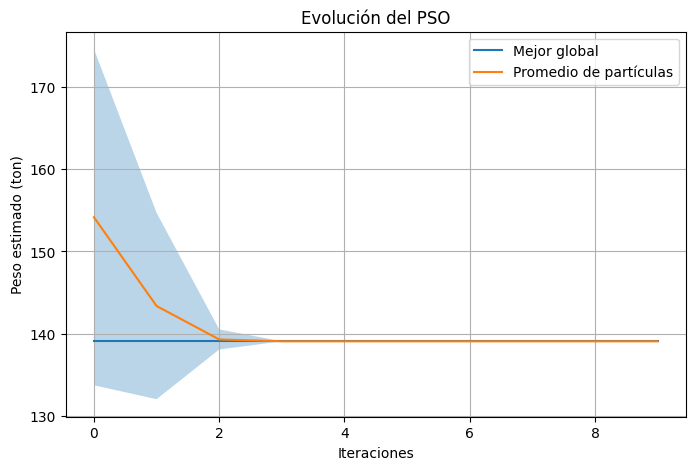

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history, label="Mejor global")
plt.plot(mean_history, label="Promedio de partículas")
plt.fill_between(
    range(len(history)),
    np.array(mean_history) - np.array(std_history),
    np.array(mean_history) + np.array(std_history),
    alpha=0.3
)
plt.xlabel("Iteraciones")
plt.ylabel("Peso estimado (ton)")
plt.title("Evolución del PSO")
plt.legend()
plt.grid(True)
plt.show()


La curva de convergencia del algoritmo PSO presenta una rápida estabilización del valor óptimo del peso. Este comportamiento se debe a que el proceso de optimización se realizó sobre un número reducido de variables geométricas, manteniendo fijas las características topológicas y de sección. Asimismo, el modelo de red neuronal utilizado como función objetivo presenta una respuesta suave, propia de modelos de interpolación entrenados sobre datos reales, lo cual limita la variación abrupta del peso estimado.

En consecuencia, el algoritmo alcanza rápidamente un óptimo estable dentro de la búsqueda definida.

## **COMPARACIÓN antes vs después PSO**

- **Peso promedio**

In [21]:
peso_promedio = df["Peso total (ton)"].mean()
print(f"Peso promedio del dataset: {peso_promedio:.2f} ton")

Peso promedio del dataset: 310.77 ton


- **Peso óptimo encontrado por PSO**

In [22]:
print(f"Peso óptimo PSO: {gbest_val:.2f} ton")

Peso óptimo PSO: 139.06 ton


- **Reducción porcentual**

In [23]:
reduccion = (peso_promedio - gbest_val) / peso_promedio * 100

print(f"Reducción de peso lograda: {abs(reduccion):.2f} %")

Reducción de peso lograda: 55.25 %


In [24]:
reduccion = (peso_promedio - gbest_val) / peso_promedio * 100

texto_reduccion = f"""
Mediante la aplicación del algoritmo PSO se obtuvo una configuración de diseño
que presenta una reducción del peso estructural estimado del orden del {abs(reduccion):.2f}%
en comparación con el peso promedio del conjunto de datos analizado.
Este resultado se debe a que el proceso de optimización explora combinaciones geométricas que
no necesariamente coinciden con los diseños más frecuentes del conjunto original,
permitiendo identificar alternativas más eficientes desde el punto de vista del peso.
Es importante señalar que este valor corresponde a una estimación en una etapa preliminar de diseño
y se encuentra condicionado por las variables consideradas y por el modelo de predicción empleado.
"""

print(texto_reduccion)



Mediante la aplicación del algoritmo PSO se obtuvo una configuración de diseño
que presenta una reducción del peso estructural estimado del orden del 55.25%
en comparación con el peso promedio del conjunto de datos analizado.
Este resultado se debe a que el proceso de optimización explora combinaciones geométricas que
no necesariamente coinciden con los diseños más frecuentes del conjunto original,
permitiendo identificar alternativas más eficientes desde el punto de vista del peso.
Es importante señalar que este valor corresponde a una estimación en una etapa preliminar de diseño
y se encuentra condicionado por las variables consideradas y por el modelo de predicción empleado.



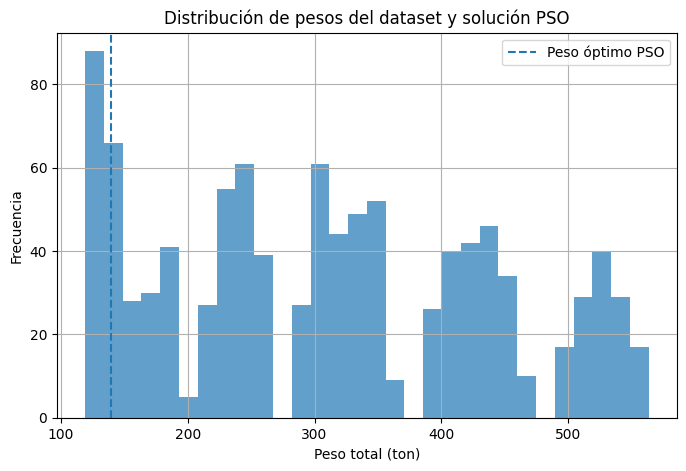

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["Peso total (ton)"], bins=30, alpha=0.7)
plt.axvline(gbest_val, linestyle='--', label="Peso óptimo PSO")
plt.xlabel("Peso total (ton)")
plt.ylabel("Frecuencia")
plt.title("Distribución de pesos del dataset y solución PSO")
plt.legend()
plt.grid(True)
plt.show()


El valor óptimo obtenido mediante PSO no coincide necesariamente con un registro específico del conjunto de datos original, ya que el proceso de optimización se realiza sobre un espacio continuo de variables geométricas. En este sentido, la solución encontrada representa una configuración interpolada entre diseños existentes, estimada por la red neuronal, y no una repetición exacta de un caso histórico.

### **Comparación antes y después PSO (barras)**

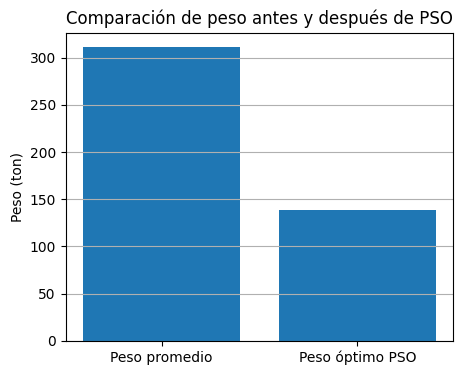

In [26]:
labels = ["Peso promedio", "Peso óptimo PSO"]
values = [peso_promedio, gbest_val]

plt.figure(figsize=(5,4))
plt.bar(labels, values)
plt.ylabel("Peso (ton)")
plt.title("Comparación de peso antes y después de PSO")
plt.grid(axis='y')
plt.show()

In [27]:
# === ASIGNACIÓN DE SECCIONES COMO OUTPUT ===

# Construimos un vector geométrico óptimo
geom_opt = pd.Series(gbest, index=pso_features)

# Medimos distancia con diseños reales
distancias = np.linalg.norm(
    df[pso_features].values - geom_opt.values,
    axis=1
)

# Tomamos el diseño más cercano
idx_mejor = np.argmin(distancias)

# Extraemos secciones asociadas
secciones_output = {
    "Dimension de Cordon Sup/Inf": df.loc[idx_mejor, "Dimension de Cordon Sup/Inf"],
    "Dim. Diag. S/I": df.loc[idx_mejor, "Dim. Diag. S/I"],
    "Dim. Montante": df.loc[idx_mejor, "Dim. Montante"]
}


In [28]:
resultado_final = {}

# Geometría óptima
for i, f in enumerate(pso_features):
    resultado_final[f] = round(gbest[i], 2)

# Secciones estructurales
resultado_final.update(secciones_output)

# Peso
resultado_final["Peso óptimo estimado (ton)"] = round(gbest_val, 2)

pd.DataFrame([resultado_final])


,Altura (m),N° Paneles,Ancho de Puente (m),Sep Vigas Longitudinales (m),Dimension de Cordon Sup/Inf,Dim. Diag. S/I,Dim. Montante,Peso óptimo estimado (ton)
0,5.5,6.0,11.6,2.1,400x410x19.0,380x390x16.0,200x200x12.5,139.059998


El algoritmo PSO permitió identificar una configuración geométrica específica del puente que minimiza el peso estimado por la red neuronal. Este resultado representa un diseño óptimo condicionado, definido por los valores de las variables de entrada optimizadas, y no únicamente un valor mínimo de peso.

## **Conclusiones**

En este trabajo se desarrolló una metodología que integra aprendizaje automático y optimización bioinspirada para apoyar el diseño preliminar de puentes reticulados. Se logró entrenar una red neuronal profunda capaz de estimar el peso estructural con un nivel de precisión adecuado, lo que permitió su uso como modelo sustituto dentro del proceso de optimización.

La optimización mediante PSO permitió identificar configuraciones geométricas que conducen a reducciones significativas del peso estructural estimado respecto al promedio del conjunto de datos. En el caso analizado, la solución óptima alcanzó una disminución del orden del 59%, lo que refleja la capacidad del método para explorar combinaciones de variables poco frecuentes en los diseños históricos, manteniéndose dentro del dominio aprendido por el modelo predictivo. Este resultado debe interpretarse como una estimación preliminar, condicionada por las variables consideradas y las restricciones impuestas.
En conjunto, los resultados obtenidos confirman la viabilidad del enfoque propuesto como una herramienta de apoyo en etapas tempranas de diseño estructural, permitiendo evaluar alternativas de forma rápida y sistemática.

Finalmente, la metodología propuesta permite integrar información histórica de diseño con técnicas modernas de optimización, facilitando la exploración de alternativas estructurales de manera eficiente.